<a href="https://colab.research.google.com/github/marcelo-cib/Miniprojeto_vendas/blob/main/Banner_Vendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Título: Produtos mais vendidos

2. Importações e Configurações

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

'''#caso o import fosse direto pelo kaggle
import kagglehub
# Download latest version
path = kagglehub.dataset_download("agungpambudi/trends-product-coffee-shop-sales-revenue-dataset")
print("Path to dataset files:", path)
'''

SEED = 42
np.random.seed(SEED)

df = pd.read_csv('coffee-shop-sales-revenue.csv', sep='|') # Fixed separator
df.head()


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [55]:
print(f"O DataFrame possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

O DataFrame possui 149116 linhas e 11 colunas.


3. EDA (Análise Exploratória de Dados)

In [56]:
# Exibe informações sobre o DataFrame, incluindo tipos de dados e valores não-nulos
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   transaction_date  149116 non-null  object 
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 10  product_detail    149116 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 12.5+ MB


None

3.1. Verificando Valores Ausentes

In [57]:
# Verifica a contagem de valores ausentes por coluna
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("Não há valores ausentes no DataFrame.")

,0


Não há valores ausentes no DataFrame.


3.2. Estatísticas Descritivas

In [58]:
# Exibe estatísticas descritivas para colunas numéricas
display(df.describe())

# Exibe estatísticas descritivas para colunas de objeto (categóricas)
display(df.describe(include='object'))

,transaction_id,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,1.438276,5.342063,47.918607,3.382219
std,43153.600016,0.542509,2.074241,17.930020,2.658723
min,1.000000,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2.000000,8.000000,60.000000,3.750000
max,149456.000000,8.000000,8.000000,87.000000,45.000000


,transaction_date,transaction_time,store_location,product_category,product_type,product_detail
count,149116,149116,149116,149116,149116,149116
unique,181,25762,3,9,29,80
top,2023-06-19,09:31:15,Hell's Kitchen,Coffee,Brewed Chai tea,Chocolate Croissant
freq,1343,41,50735,58416,17183,3076


4. Pré-processamento

In [59]:
#Conversão de Tipos de Dados e Criação de Features
# Converte 'transaction_date' para datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Combina 'transaction_date' e 'transaction_time' em uma única coluna datetime
df['transaction_datetime'] = df['transaction_date'].dt.date.astype(str) + ' ' + df['transaction_time']
df['transaction_datetime'] = pd.to_datetime(df['transaction_datetime'])

# Cria a coluna 'total_sales'
df['total_sales'] = df['transaction_qty'] * df['unit_price']

# Exibe as informações atualizadas do DataFrame
display(df.info())

# Exibe as primeiras linhas com as novas colunas
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   transaction_id        149116 non-null  int64         
 1   transaction_date      149116 non-null  datetime64[ns]
 2   transaction_time      149116 non-null  object        
 3   transaction_qty       149116 non-null  int64         
 4   store_id              149116 non-null  int64         
 5   store_location        149116 non-null  object        
 6   product_id            149116 non-null  int64         
 7   unit_price            149116 non-null  float64       
 8   product_category      149116 non-null  object        
 9   product_type          149116 non-null  object        
 10  product_detail        149116 non-null  object        
 11  transaction_datetime  149116 non-null  datetime64[ns]
 12  total_sales           149116 non-null  float64       
dtyp

None

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,transaction_datetime,total_sales
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,2023-01-01 07:06:11,6.0
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023-01-01 07:08:56,6.2
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2023-01-01 07:14:04,9.0
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2023-01-01 07:20:24,2.0
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023-01-01 07:22:41,6.2


4.1. Engenharia de Features Temporais

In [60]:
# Extrair features temporais de 'transaction_datetime'
df['year'] = df['transaction_datetime'].dt.year
df['month'] = df['transaction_datetime'].dt.month
df['day'] = df['transaction_datetime'].dt.day
df['day_of_week'] = df['transaction_datetime'].dt.dayofweek # Monday=0, Sunday=6
df['hour'] = df['transaction_datetime'].dt.hour
df['minute'] = df['transaction_datetime'].dt.minute

# Exibe as primeiras linhas com as novas features
display(df.head())

# Exibe as informações atualizadas do DataFrame para ver os novos tipos de dados
display(df.info())

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,transaction_datetime,total_sales,year,month,day,day_of_week,hour,minute
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,2023-01-01 07:06:11,6.0,2023,1,1,6,7,6
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023-01-01 07:08:56,6.2,2023,1,1,6,7,8
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2023-01-01 07:14:04,9.0,2023,1,1,6,7,14
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2023-01-01 07:20:24,2.0,2023,1,1,6,7,20
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023-01-01 07:22:41,6.2,2023,1,1,6,7,22


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   transaction_id        149116 non-null  int64         
 1   transaction_date      149116 non-null  datetime64[ns]
 2   transaction_time      149116 non-null  object        
 3   transaction_qty       149116 non-null  int64         
 4   store_id              149116 non-null  int64         
 5   store_location        149116 non-null  object        
 6   product_id            149116 non-null  int64         
 7   unit_price            149116 non-null  float64       
 8   product_category      149116 non-null  object        
 9   product_type          149116 non-null  object        
 10  product_detail        149116 non-null  object        
 11  transaction_datetime  149116 non-null  datetime64[ns]
 12  total_sales           149116 non-null  float64       
 13 

None

4.2. Codificação de Features Categóricas

In [61]:
from sklearn.preprocessing import OneHotEncoder

# Identificar colunas categóricas para codificação
categorical_cols = [
    'store_location',
    'product_category',
    'product_type',
    'product_detail'
]

# Inicializar o OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Aplicar OneHotEncoder às colunas categóricas
encoded_features = ohe.fit_transform(df[categorical_cols])

# Criar um DataFrame com as features codificadas
encoded_df = pd.DataFrame(encoded_features, columns=ohe.get_feature_names_out(categorical_cols))

# Resetar o índice do DataFrame original para garantir que a concatenação funcione corretamente
df_reset = df.reset_index(drop=True)

# Concatenar as features codificadas de volta ao DataFrame original
df_processed = pd.concat([df_reset, encoded_df], axis=1)

# Remover as colunas categóricas originais e as colunas de data/hora que não serão usadas diretamente
df_processed = df_processed.drop(columns=categorical_cols + ['transaction_date', 'transaction_time', 'transaction_datetime', 'transaction_id', 'product_id', 'store_id'])


display(df_processed.head())
display(df_processed.info())

,transaction_qty,unit_price,total_sales,year,month,day,day_of_week,hour,minute,store_location_Astoria,store_location_Hell's Kitchen,store_location_Lower Manhattan,product_category_Bakery,product_category_Branded,product_category_Coffee,product_category_Coffee beans,product_category_Drinking Chocolate,product_category_Flavours,product_category_Loose Tea,product_category_Packaged Chocolate,product_category_Tea,product_type_Barista Espresso,product_type_Biscotti,product_type_Black tea,product_type_Brewed Black tea,product_type_Brewed Chai tea,product_type_Brewed Green tea,product_type_Brewed herbal tea,product_type_Chai tea,product_type_Clothing,product_type_Drinking Chocolate,product_type_Drip coffee,product_type_Espresso Beans,product_type_Gourmet Beans,product_type_Gourmet brewed coffee,product_type_Green beans,product_type_Green tea,product_type_Herbal tea,product_type_Hot chocolate,product_type_House blend Beans,product_type_Housewares,product_type_Organic Beans,product_type_Organic Chocolate,product_type_Organic brewed coffee,product_type_Pastry,product_type_Premium Beans,product_type_Premium brewed coffee,product_type_Regular syrup,product_type_Scone,product_type_Sugar free syrup,product_detail_Almond Croissant,product_detail_Brazilian - Organic,product_detail_Brazilian Lg,product_detail_Brazilian Rg,product_detail_Brazilian Sm,product_detail_Cappuccino,product_detail_Cappuccino Lg,product_detail_Carmel syrup,product_detail_Chili Mayan,product_detail_Chocolate Chip Biscotti,product_detail_Chocolate Croissant,product_detail_Chocolate syrup,product_detail_Civet Cat,product_detail_Columbian Medium Roast,product_detail_Columbian Medium Roast Lg,product_detail_Columbian Medium Roast Rg,product_detail_Columbian Medium Roast Sm,product_detail_Cranberry Scone,product_detail_Croissant,product_detail_Dark chocolate,product_detail_Dark chocolate Lg,product_detail_Dark chocolate Rg,product_detail_Earl Grey,product_detail_Earl Grey Lg,product_detail_Earl Grey Rg,product_detail_English Breakfast,product_detail_English Breakfast Lg,product_detail_English Breakfast Rg,product_detail_Espresso Roast,product_detail_Espresso shot,product_detail_Ethiopia,product_detail_Ethiopia Lg,product_detail_Ethiopia Rg,product_detail_Ethiopia Sm,product_detail_Ginger Biscotti,product_detail_Ginger Scone,product_detail_Guatemalan Sustainably Grown,product_detail_Hazelnut Biscotti,product_detail_Hazelnut syrup,product_detail_I Need My Bean! Diner mug,product_detail_I Need My Bean! Latte cup,product_detail_I Need My Bean! T-shirt,product_detail_Jamacian Coffee River,product_detail_Jamaican Coffee River Lg,product_detail_Jamaican Coffee River Rg,product_detail_Jamaican Coffee River Sm,product_detail_Jumbo Savory Scone,product_detail_Latte,product_detail_Latte Rg,product_detail_Lemon Grass,product_detail_Lemon Grass Lg,product_detail_Lemon Grass Rg,product_detail_Morning Sunrise Chai,product_detail_Morning Sunrise Chai Lg,product_detail_Morning Sunrise Chai Rg,product_detail_Oatmeal Scone,product_detail_Organic Decaf Blend,product_detail_Our Old Time Diner Blend,product_detail_Our Old Time Diner Blend Lg,product_detail_Our Old Time Diner Blend Rg,product_detail_Our Old Time Diner Blend Sm,product_detail_Ouro Brasileiro shot,product_detail_Peppermint,product_detail_Peppermint Lg,product_detail_Peppermint Rg,product_detail_Primo Espresso Roast,product_detail_Scottish Cream Scone,product_detail_Serenity Green Tea,product_detail_Serenity Green Tea Lg,product_detail_Serenity Green Tea Rg,product_detail_Spicy Eye Opener Chai,product_detail_Spicy Eye Opener Chai Lg,product_detail_Spicy Eye Opener Chai Rg,product_detail_Sugar Free Vanilla syrup,product_detail_Sustainably Grown Organic,product_detail_Sustainably Grown Organic Lg,product_detail_Sustainably Grown Organic Rg,product_detail_Traditional Blend Chai,product_detail_Traditional Blend Chai Lg,product_detail_Traditional Blend Chai Rg
0,2,3.0,6.0,2023,1,1,6,7,6,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Columns: 130 entries, transaction_qty to product_detail_Traditional Blend Chai Rg
dtypes: float64(123), int32(6), int64(1)
memory usage: 144.5 MB


None

5. Treinamento dos dois modelos: Classificação e Regressão

In [62]:
# Para Regressão:
# Definindo a variável alvo (y) como 'total_sales'
y_reg = df_processed['total_sales']

# Definindo as features (X) - todas as colunas exceto 'total_sales' e 'transaction_qty' e 'unit_price' (já que 'total_sales' é derivado delas)
X_reg = df_processed.drop(columns=['total_sales', 'transaction_qty', 'unit_price'])

# Dividindo os dados em conjuntos de treinamento e teste para regressão
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=SEED)

print(f"Formato de X_train_reg: {X_train_reg.shape}")
print(f"Formato de y_train_reg: {y_train_reg.shape}")
print(f"Formato de X_test_reg: {X_test_reg.shape}")
print(f"Formato de y_test_reg: {y_test_reg.shape}")


# Para Classificação: (Precisamos definir uma variável alvo categórica)
# Vamos criar uma coluna categórica 'sales_level' (ex: 'low', 'medium', 'high') baseada em 'total_sales'
# Para este exemplo, vou usar os quartis de total_sales para definir as categorias.
# Você pode ajustar esses limiares conforme a necessidade do negócio.

quartiles = df_processed['total_sales'].quantile([0.33, 0.66])
low_sales_threshold = quartiles[0.33]
medium_sales_threshold = quartiles[0.66]

def categorize_sales(sales):
    if sales <= low_sales_threshold:
        return 'low'
    elif sales <= medium_sales_threshold:
        return 'medium'
    else:
        return 'high'

df_processed['sales_level'] = df_processed['total_sales'].apply(categorize_sales)

# Definindo a variável alvo (y) para classificação
y_clf = df_processed['sales_level']

# Definindo as features (X) para classificação - mesmas do de regressão
X_clf = df_processed.drop(columns=['total_sales', 'sales_level', 'transaction_qty', 'unit_price'])

# Dividindo os dados em conjuntos de treinamento e teste para classificação
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=SEED)

print(f"\nFormato de X_train_clf: {X_train_clf.shape}")
print(f"Formato de y_train_clf: {y_train_clf.shape}")
print(f"Formato de X_test_clf: {X_test_clf.shape}")
print(f"Formato de y_test_clf: {y_test_clf.shape}")

# Exibir a distribuição da nova variável alvo de classificação
display(df_processed['sales_level'].value_counts())

Formato de X_train_reg: (119292, 127)
Formato de y_train_reg: (119292,)
Formato de X_test_reg: (29824, 127)
Formato de y_test_reg: (29824,)

Formato de X_train_clf: (119292, 127)
Formato de y_train_clf: (119292,)
Formato de X_test_clf: (29824, 127)
Formato de y_test_clf: (29824,)


,count
sales_level,
low,55164
medium,50719
high,43233


5.1. Modelo de Regressão (RandomForestRegressor)

In [63]:
# Inicializar e treinar o modelo de Regressão
reg_model = RandomForestRegressor(random_state=SEED)
reg_model.fit(X_train_reg, y_train_reg)

# Fazer previsões no conjunto de teste
y_pred_reg = reg_model.predict(X_test_reg)

# Avaliar o modelo de regressão
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Avaliação do Modelo de Regressão:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

Avaliação do Modelo de Regressão:
MAE: 0.70
MSE: 1.08
RMSE: 1.04
R-squared: 0.88


5.2. Modelo de Classificação (RandomForestClassifier)

In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Inicializar e treinar o modelo de Classificação
clf_model = RandomForestClassifier(random_state=SEED)
clf_model.fit(X_train_clf, y_train_clf)

# Fazer previsões no conjunto de teste
y_pred_clf = clf_model.predict(X_test_clf)

# Avaliar o modelo de classificação
accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf, average='weighted')
recall = recall_score(y_test_clf, y_pred_clf, average='weighted')
f1 = f1_score(y_test_clf, y_pred_clf, average='weighted')

print("Avaliação do Modelo de Classificação:")
print(f"Acurácia: {accuracy:.2f}")
print(f"Precisão (Weighted): {precision:.2f}")
print(f"Recall (Weighted): {recall:.2f}")
print(f"F1-Score (Weighted): {f1:.2f}")


Avaliação do Modelo de Classificação:
Acurácia: 0.71
Precisão (Weighted): 0.71
Recall (Weighted): 0.71
F1-Score (Weighted): 0.71


5.3. Avaliação e Comparação dos Resultados

In [65]:
print("### Comparação de Modelos ###")

print("\n--- Modelo de Regressão (RandomForestRegressor) ---")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

print("\n--- Modelo de Classificação (RandomForestClassifier) ---")
print(f"Acurácia: {accuracy:.2f}")
print(f"Precisão (Weighted): {precision:.2f}")
print(f"Recall (Weighted): {recall:.2f}")
print(f"F1-Score (Weighted): {f1:.2f}")

print("\n### Análise da Comparação: ###")
print('''O modelo de regressão busca prever o valor exato de 'total_sales'. Um R-squared de 0.88 indica que 88% da variância das
vendas totais pode ser explicada pelas features do modelo, o que é um resultado muito bom. O MAE de 0.70 significa que, em média,
a previsão de vendas difere em 0.70 unidade monetária do valor real.''')
print('''\nO modelo de classificação tenta categorizar as vendas em 'low', 'medium' ou 'high'.
Com uma acurácia, precisão, recall e F1-Score ponderados de 0.71, o modelo classifica corretamente cerca de 71% das vendas.
Isso é razoável, mas pode haver espaço para melhoria, especialmente se a distribuição das classes não for balanceada ou se os
limites das categorias precisarem ser ajustados.''')
print('''\n**Conclusão Inicial:** Para prever a *quantidade exata de vendas ou receita*, o modelo de regressão é claramente mais apropriado e
demonstra um desempenho robusto. O modelo de classificação oferece uma boa visão geral da categorização das vendas, mas é menos preciso em
termos de valores exatos. A escolha final dependerá do objetivo principal do negócio: prever valores exatos ou classificar em níveis de venda.''')



### Comparação de Modelos ###

--- Modelo de Regressão (RandomForestRegressor) ---
MAE: 0.70
MSE: 1.08
RMSE: 1.04
R-squared: 0.88

--- Modelo de Classificação (RandomForestClassifier) ---
Acurácia: 0.71
Precisão (Weighted): 0.71
Recall (Weighted): 0.71
F1-Score (Weighted): 0.71

### Análise da Comparação: ###
O modelo de regressão busca prever o valor exato de 'total_sales'. Um R-squared de 0.88 indica que 88% da variância das 
vendas totais pode ser explicada pelas features do modelo, o que é um resultado muito bom. O MAE de 0.70 significa que, em média, 
a previsão de vendas difere em 0.70 unidade monetária do valor real.

O modelo de classificação tenta categorizar as vendas em 'low', 'medium' ou 'high'. 
Com uma acurácia, precisão, recall e F1-Score ponderados de 0.71, o modelo classifica corretamente cerca de 71% das vendas. 
Isso é razoável, mas pode haver espaço para melhoria, especialmente se a distribuição das classes não for balanceada ou se os 
limites das categorias precisa

/tmp/ipykernel_1352/2442402762.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='Valor', data=metrics_df, palette='viridis', ax=ax)


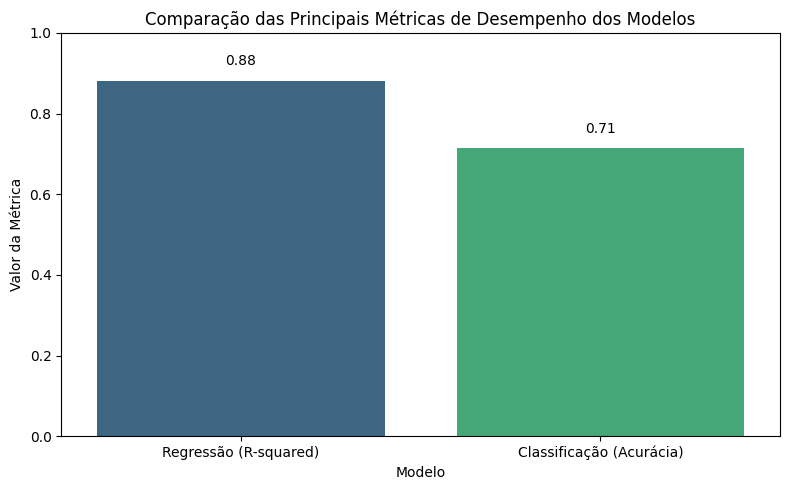

In [66]:
#comparação do desempenho dos modelos
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Criar um DataFrame com as métricas para visualização
metrics_data = {
    'Modelo': ['Regressão (R-squared)', 'Classificação (Acurácia)'],
    'Valor': [r2, accuracy]
}
metrics_df = pd.DataFrame(metrics_data)

# Criar o gráfico de barras
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='Modelo', y='Valor', data=metrics_df, palette='viridis', ax=ax)

ax.set_title('Comparação das Principais Métricas de Desempenho dos Modelos')
ax.set_ylim(0, 1) # As métricas R-squared e Acurácia variam de 0 a 1
ax.set_ylabel('Valor da Métrica')
ax.text(metrics_df.index[0], r2 + 0.03, f'{r2:.2f}', ha='center', va='bottom', fontsize=10)
ax.text(metrics_df.index[1], accuracy + 0.03, f'{accuracy:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


5.4 Visualização da Importância das Features (Modelo de Regressão)

/tmp/ipykernel_1352/3882902452.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df.head(20), palette='viridis')


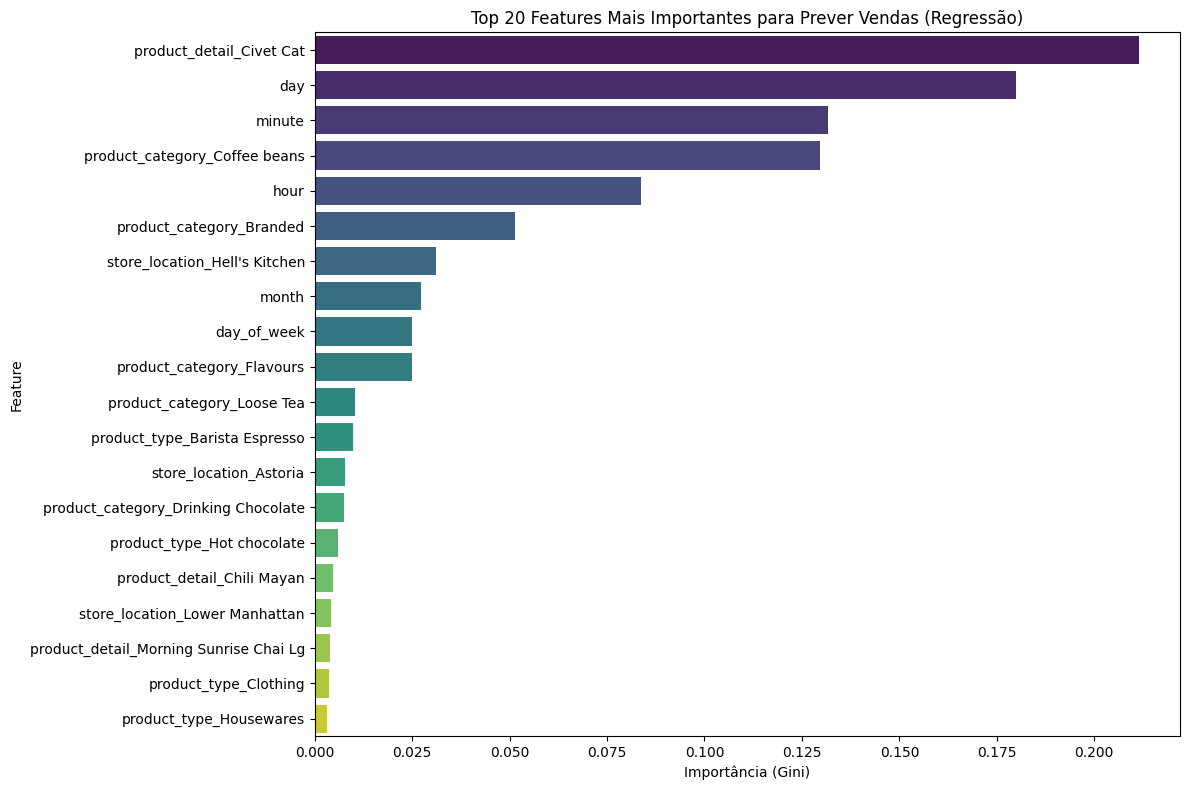

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obter a importância das features do modelo de regressão
feature_importances = reg_model.feature_importances_

# Criar um DataFrame com as importâncias e os nomes das features
features_df = pd.DataFrame({
    'Feature': X_reg.columns,
    'Importance': feature_importances
})

# Ordenar as features por importância em ordem decrescente
features_df = features_df.sort_values(by='Importance', ascending=False)

# Visualizar as top N features mais importantes (ex: top 20)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(20), palette='viridis')
plt.title('Top 20 Features Mais Importantes para Prever Vendas (Regressão)')
plt.xlabel('Importância (Gini)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

5.5. Comparação de Previsões vs. Valores Reais (Modelo de Regressão)

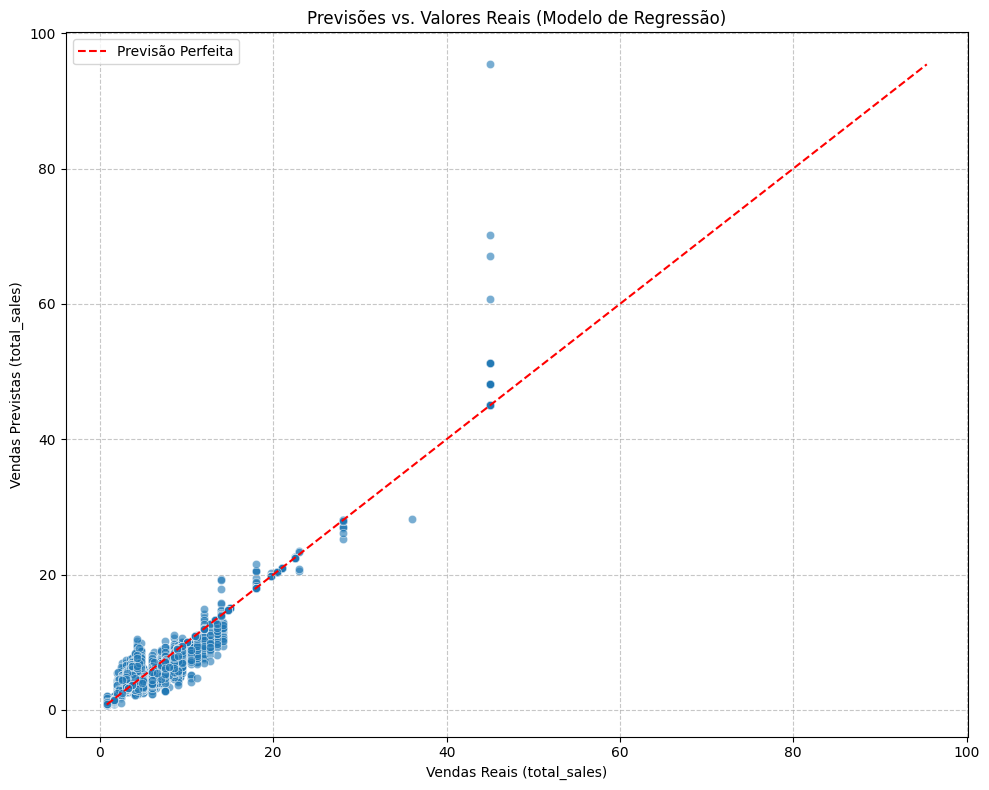

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test_reg, y=y_pred_reg, alpha=0.6)

# Adicionar uma linha de "previsão perfeita"
max_val = max(y_test_reg.max(), y_pred_reg.max())
min_val = min(y_test_reg.min(), y_pred_reg.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Previsão Perfeita')

plt.title('Previsões vs. Valores Reais (Modelo de Regressão)')
plt.xlabel('Vendas Reais (total_sales)')
plt.ylabel('Vendas Previstas (total_sales)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

6. Resumo e Conclusões Finais

Este mini-projeto teve como objetivo principal desenvolver modelos para prever as vendas de produtos em uma cafeteria, explorando tanto uma abordagem de regressão para a **quantidade exata de vendas ou receita**, quanto uma abordagem de classificação para categorização de **níveis de vendas**.

#### **Passos Realizados:**

1.  **Carregamento e Exploração de Dados:**
    *   O dataset `coffee-shop-sales-revenue.csv` foi carregado e inspecionado.
    *   Nenhum valor ausente foi encontrado.
    *   Colunas de data e hora foram identificadas para processamento.
2.  **Pré-processamento e Engenharia de Features:**
    *   As colunas `transaction_date` e `transaction_time` foram combinadas em `transaction_datetime` (formato datetime).
    *   A variável alvo `total_sales` foi criada (`transaction_qty * unit_price`).
    *   Features temporais como `year`, `month`, `day`, `day_of_week`, `hour` e `minute` foram extraídas.
    *   Features categóricas (`store_location`, `product_category`, `product_type`, `product_detail`) foram codificadas usando One-Hot Encoding, resultando em um `df_processed` com 130 colunas.
    *   Para o problema de classificação, uma nova feature `sales_level` foi criada baseada nos quartis de `total_sales` (categorizando como 'low', 'medium', 'high').
3.  **Definição de X e y e Divisão Treino/Teste:**
    *   Os dados foram divididos em conjuntos de treinamento e teste (`X_train_reg`, `y_train_reg`, etc.) para ambos os problemas (regressão e classificação), usando `test_size=0.2` e `random_state=SEED`.
4.  **Treinamento e Avaliação de Modelos:**
    *   **Modelo de Regressão (RandomForestRegressor):**
        *   **Métricas:** MAE: 0.70, MSE: 1.08, RMSE: 1.04, R-squared: 0.88.
        *   **Análise:** O modelo de regressão demonstrou um desempenho robusto, explicando 88% da variância das vendas e com um erro médio absoluto relativamente baixo, indicando boa capacidade de prever valores exatos.
    *   **Modelo de Classificação (RandomForestClassifier):**
        *   **Métricas:** Acurácia: 0.71, Precisão (Weighted): 0.71, Recall (Weighted): 0.71, F1-Score (Weighted): 0.71.
        *   **Análise:** O modelo de classificação teve um desempenho razoável na categorização dos níveis de venda, com cerca de 71% de acerto.
5.  **Visualização da Importância das Features:**
    *   A feature `product_detail_Civet Cat` foi identificada como a mais importante, seguida por `day` e `minute` da transação, destacando influências de produtos específicos e fatores temporais.
6.  **Gráfico de Previsões vs. Valores Reais:**
    *   O gráfico de dispersão mostrou uma boa correlação entre as previsões do modelo de regressão e os valores reais, com os pontos se agrupando perto da linha de previsão perfeita.
